In [1]:
# =============================================
# 0️⃣ CONFIG & IMPORTS
# =============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# For reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [2]:

# ---- Hyperparameters ----
ACTIVATION = "relu"          # Try: "relu", "leaky_relu", "tanh", "sigmoid"
HIDDEN_SIZES = [16, 8]       # Try: [4], [32, 16], [64, 32]
LEARNING_RATE = 0.001        # Try: 0.01, 0.0001
OPTIMIZER_NAME = "adam"      # Try: "sgd", "adam"
NUM_EPOCHS = 50              # Try: 20 for quick experiments
BATCH_SIZE = 32
USE_BATCH_NORM = False       # Try: True / False
DROPOUT_P = 0.0              # Try: 0.3 to see effect of dropout

VAL_RATIO = 0.1              # 10% for validation
TEST_RATIO = 0.2             # 20% for test


In [3]:
# =============================================
# 1️⃣ LOAD DATA & BASIC INFO
# =============================================

data = pd.read_csv("Insurance.csv")
print("✅ Dataset loaded successfully!\n")
print(data.head(), "\n")

print("🔹 Info:")
print(data.info())
print("\n🔹 Missing values:\n", data.isnull().sum())
print("\n🔹 Summary statistics:\n", data.describe())

✅ Dataset loaded successfully!

   age  sex     bmi  children  smoker  region      charges  insuranceclaim
0   19    0  27.900         0       1       3  16884.92400               1
1   18    1  33.770         1       0       2   1725.55230               1
2   28    1  33.000         3       0       2   4449.46200               0
3   33    1  22.705         0       0       1  21984.47061               0
4   32    1  28.880         0       0       1   3866.85520               1 

🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1338 non-null   int64  
 1   sex             1338 non-null   int64  
 2   bmi             1338 non-null   float64
 3   children        1338 non-null   int64  
 4   smoker          1338 non-null   int64  
 5   region          1338 non-null   int64  
 6   charges         1338 non-null   float

C:\Users\abhin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


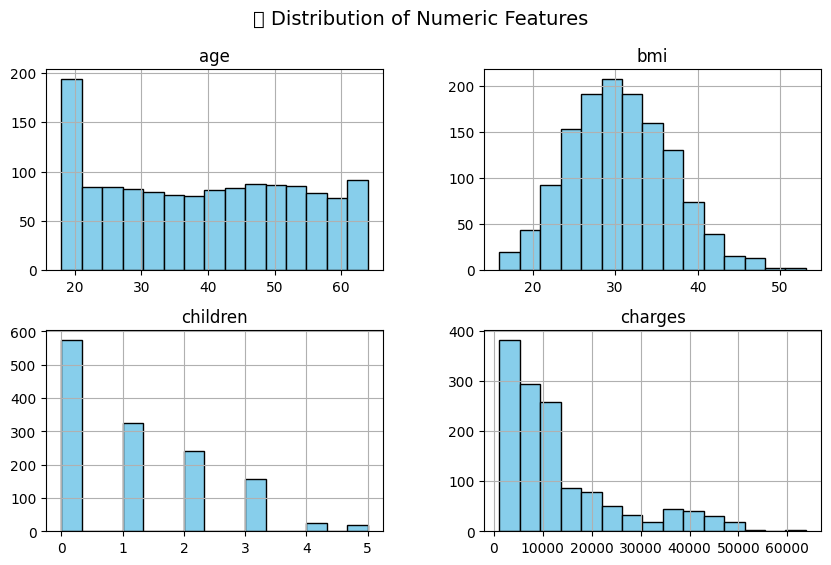

C:\Users\abhin\AppData\Local\Temp\ipykernel_6976\3726601800.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette='Set2')
C:\Users\abhin\AppData\Local\Temp\ipykernel_6976\3726601800.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette='Set2')
C:\Users\abhin\AppData\Local\Temp\ipykernel_6976\3726601800.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette='Set2')
C:\Users\abhin\AppData\Local\Temp\ipykernel_6976\3726601800.py:14: FutureWarning: 

Passing `palette` without assig

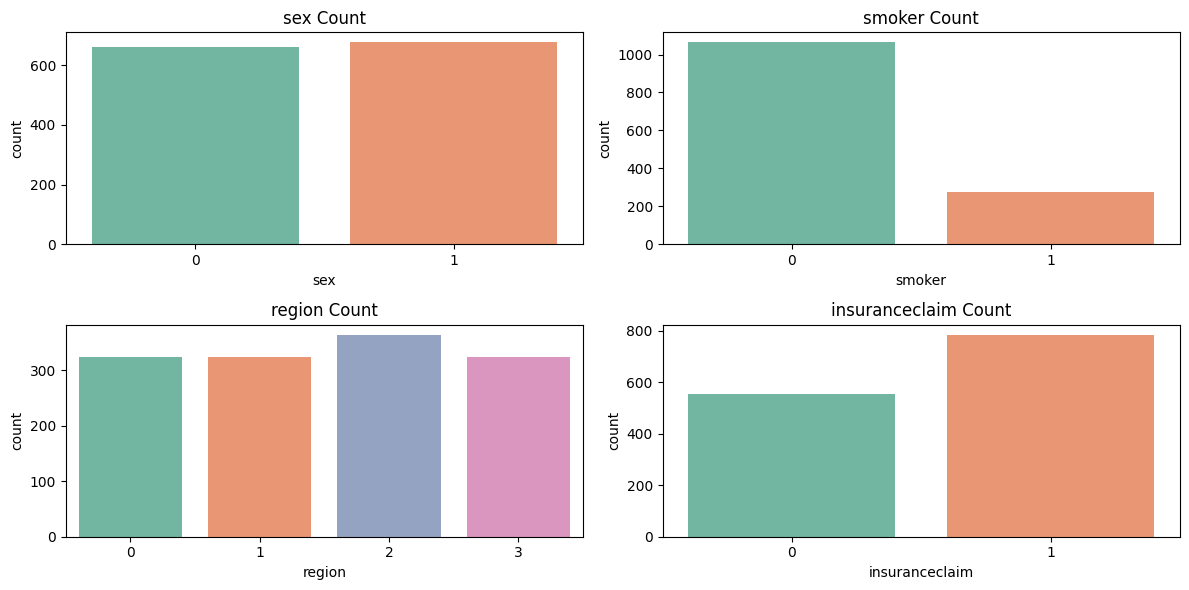

C:\Users\abhin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


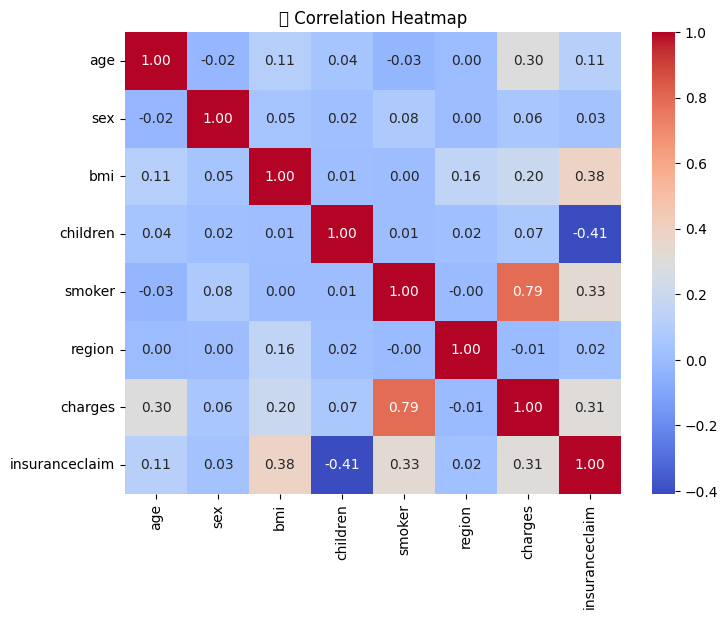

C:\Users\abhin\AppData\Local\Temp\ipykernel_6976\3726601800.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=data, palette="Set3")
C:\Users\abhin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


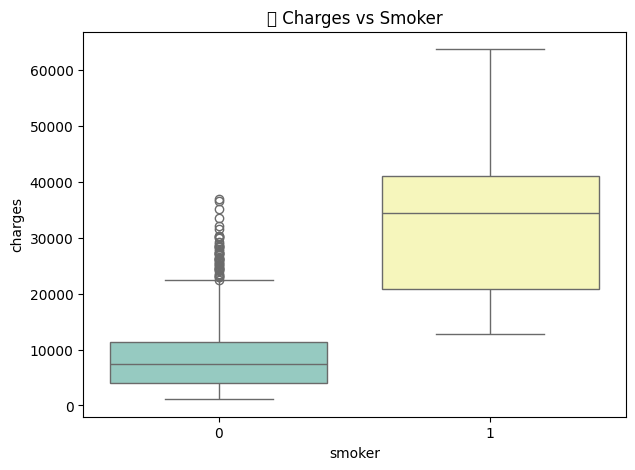

In [4]:
# =============================================
# 2️⃣ EXPLORATORY DATA ANALYSIS
# =============================================

num_features = ['age', 'bmi', 'children', 'charges']
data[num_features].hist(bins=15, figsize=(10, 6), color='skyblue', edgecolor='black')
plt.suptitle("📊 Distribution of Numeric Features", fontsize=14)
plt.show()

cat_features = ['sex', 'smoker', 'region', 'insuranceclaim']
plt.figure(figsize=(12, 6))
for i, col in enumerate(cat_features, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=data[col], palette='Set2')
    plt.title(f"{col} Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("🔥 Correlation Heatmap")
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(x='smoker', y='charges', data=data, palette="Set3")
plt.title("💰 Charges vs Smoker")
plt.show()

In [5]:
# =============================================
# 3️⃣ PREPROCESSING FUNCTIONS
# =============================================

def preprocess(dataframe):
    """
    - Splits features/target
    - One-hot encodes categoricals
    - Scales numeric features
    - Returns tensors ready for PyTorch
    """
    # Separate features and target
    X = dataframe.drop('insuranceclaim', axis=1)
    y = dataframe['insuranceclaim'].values

    # One-hot encode categorical variables
    X = pd.get_dummies(X, columns=['sex', 'region', 'smoker'], drop_first=True)

    # Handle missing values
    X.fillna(X.mean(), inplace=True)

    # Scale numerical columns
    num_cols = ['age', 'bmi', 'children', 'charges']
    scaler = StandardScaler()
    X[num_cols] = scaler.fit_transform(X[num_cols])

    # Convert boolean columns to integers (0/1)
    for col in X.select_dtypes('bool').columns:
        X[col] = X[col].astype(int)

    # Ensure all columns are numeric
    X = X.apply(pd.to_numeric, errors='coerce')
    X.fillna(0, inplace=True)  # Fill any remaining NaNs with 0

    print("\n✅ After encoding and scaling:")
    print(X.head())
    print("\n🔹 Data types:\n", X.dtypes)

    # Convert to tensors
    X_tensor = torch.tensor(X.values, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)

    return X_tensor, y_tensor, list(X.columns)


X_tensor, y_tensor, feature_names = preprocess(data)


✅ After encoding and scaling:
        age       bmi  children   charges  sex_1  region_1  region_2  \
0 -1.438764 -0.453320 -0.908614  0.298584      0         0         0   
1 -1.509965  0.509621 -0.078767 -0.953689      1         0         1   
2 -0.797954  0.383307  1.580926 -0.728675      1         0         1   
3 -0.441948 -1.305531 -0.908614  0.719843      1         1         0   
4 -0.513149 -0.292556 -0.908614 -0.776802      1         1         0   

   region_3  smoker_1  
0         1         1  
1         0         0  
2         0         0  
3         0         0  
4         0         0  

🔹 Data types:
 age         float64
bmi         float64
children    float64
charges     float64
sex_1         int64
region_1      int64
region_2      int64
region_3      int64
smoker_1      int64
dtype: object


In [6]:
# =============================================
# 4️⃣ DATASET SPLIT & DATALOADERS
# =============================================

def create_loaders(X_tensor, y_tensor, batch_size, val_ratio, test_ratio, seed=42):
    dataset = TensorDataset(X_tensor, y_tensor)
    n_total = len(dataset)
    n_test = int(n_total * test_ratio)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_test - n_val

    # Use a generator with fixed seed for reproducible splits
    generator = torch.Generator().manual_seed(seed)
    train_dataset, val_dataset, test_dataset = random_split(
        dataset,
        [n_train, n_val, n_test],
        generator=generator
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"\n📊 Train size: {n_train}")
    print(f"📊 Val size:   {n_val}")
    print(f"📊 Test size:  {n_test}")

    return train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset


train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = create_loaders(
    X_tensor, y_tensor, BATCH_SIZE, VAL_RATIO, TEST_RATIO, SEED
)


📊 Train size: 938
📊 Val size:   133
📊 Test size:  267


In [7]:
# =============================================
# 5️⃣ MODEL BUILDING
# =============================================

def get_activation(name):
    """
    Returns an activation class (not an instance) so we can create
    separate instances for each layer.
    """
    name = name.lower()
    if name == "relu":
        return nn.ReLU
    elif name == "leaky_relu":
        return nn.LeakyReLU
    elif name == "tanh":
        return nn.Tanh
    elif name == "sigmoid":
        return nn.Sigmoid
    else:
        raise ValueError(f"Unknown activation: {name}")


class NeuralNet(nn.Module):
    def __init__(self,
                 input_size,
                 hidden_sizes,
                 output_size,
                 activation_name="relu",
                 use_batch_norm=False,
                 dropout_p=0.0):
        super(NeuralNet, self).__init__()

        layers = []
        in_features = input_size
        activation_cls = get_activation(activation_name)

        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))

            if use_batch_norm:
                layers.append(nn.BatchNorm1d(h))

            layers.append(activation_cls())

            if dropout_p > 0.0:
                layers.append(nn.Dropout(p=dropout_p))

            in_features = h

        # Output layer (no activation because CrossEntropyLoss expects raw logits)
        layers.append(nn.Linear(in_features, output_size))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


input_size = X_tensor.shape[1]
output_size = len(np.unique(y_tensor.numpy()))

model = NeuralNet(
    input_size=input_size,
    hidden_sizes=HIDDEN_SIZES,
    output_size=output_size,
    activation_name=ACTIVATION,
    use_batch_norm=USE_BATCH_NORM,
    dropout_p=DROPOUT_P
).to(device)

print("\n🧠 Model architecture:")
print(model)



🧠 Model architecture:
NeuralNet(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
)


In [8]:
# =============================================
# 6️⃣ LOSS FUNCTION & OPTIMIZER 
# =============================================

criterion = nn.CrossEntropyLoss()  # For multi-class / 2-class classification

def get_optimizer(name, model_params, lr):
    name = name.lower()
    if name == "sgd":
        return optim.SGD(model_params, lr=lr, momentum=0.9)
    elif name == "adam":
        return optim.Adam(model_params, lr=lr)
    else:
        raise ValueError(f"Unknown optimizer: {name}")

optimizer = get_optimizer(OPTIMIZER_NAME, model.parameters(), LEARNING_RATE)

In [9]:
# =============================================
# 7️⃣ TRAINING & VALIDATION LOOPS
# =============================================

def train_model(model, train_loader, val_loader,
                criterion, optimizer, num_epochs, device):

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        # ---- Training ----
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)

        # ---- Validation ----
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)

                _, predicted = torch.max(outputs.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = correct / total

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Train Loss: {epoch_train_loss:.4f} | "
                  f"Val Loss: {epoch_val_loss:.4f} | "
                  f"Val Acc: {epoch_val_acc:.4f}")

    return history


history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, NUM_EPOCHS, device)

Epoch [1/50] Train Loss: 0.6635 | Val Loss: 0.6835 | Val Acc: 0.5338
Epoch [5/50] Train Loss: 0.4954 | Val Loss: 0.5181 | Val Acc: 0.7368
Epoch [10/50] Train Loss: 0.3332 | Val Loss: 0.3367 | Val Acc: 0.8872
Epoch [15/50] Train Loss: 0.2937 | Val Loss: 0.2809 | Val Acc: 0.9023
Epoch [20/50] Train Loss: 0.2689 | Val Loss: 0.2496 | Val Acc: 0.9023
Epoch [25/50] Train Loss: 0.2494 | Val Loss: 0.2299 | Val Acc: 0.9098
Epoch [30/50] Train Loss: 0.2380 | Val Loss: 0.2204 | Val Acc: 0.9173
Epoch [35/50] Train Loss: 0.2259 | Val Loss: 0.2136 | Val Acc: 0.9173
Epoch [40/50] Train Loss: 0.2171 | Val Loss: 0.2068 | Val Acc: 0.9098
Epoch [45/50] Train Loss: 0.2074 | Val Loss: 0.2037 | Val Acc: 0.9173
Epoch [50/50] Train Loss: 0.2031 | Val Loss: 0.2003 | Val Acc: 0.9173


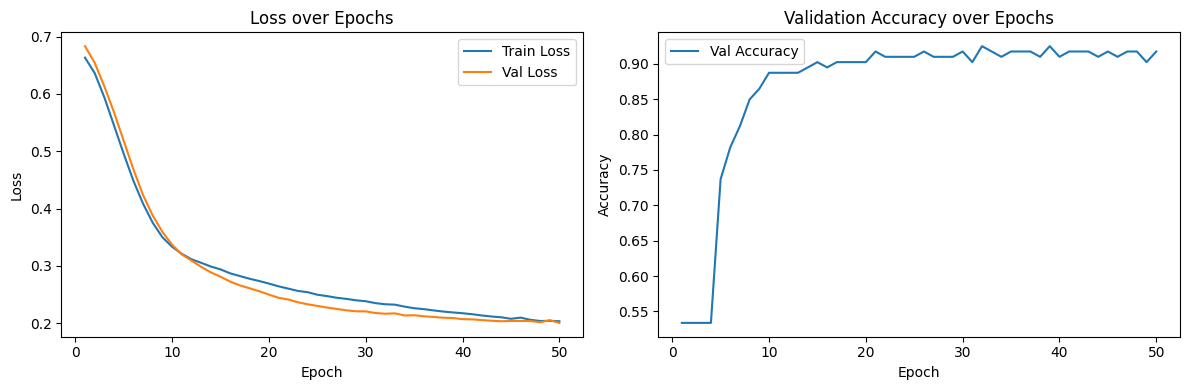

In [10]:
# =============================================
# 8️⃣ PLOT TRAINING CURVES (nice to show overfitting/underfitting)
# =============================================

def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss over Epochs")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["val_acc"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation Accuracy over Epochs")
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_history(history)


✅ Model Evaluation on Test Set:
Accuracy: 0.9138576779026217

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.96      0.90       110
           1       0.97      0.88      0.92       157

    accuracy                           0.91       267
   macro avg       0.91      0.92      0.91       267
weighted avg       0.92      0.91      0.91       267



C:\Users\abhin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


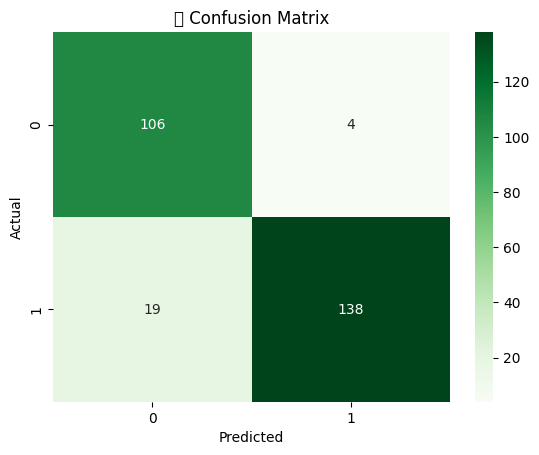

In [11]:
# =============================================
# 9️⃣ FINAL EVALUATION ON TEST SET
# =============================================

def evaluate_model(model, test_loader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            _, predicted = torch.max(outputs.data, 1)

            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    print("\n✅ Model Evaluation on Test Set:")
    print("Accuracy:", acc)
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title("🧩 Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc, y_true, y_pred


test_acc, y_true, y_pred = evaluate_model(model, test_loader, device)


In [12]:

# =============================================
# 🔟 DEMO PREDICTION ON ONE SAMPLE
# =============================================

sample = test_dataset[0][0].unsqueeze(0).to(device)  # Add batch dimension

model.eval()
with torch.no_grad():
    output = model(sample)
    _, predicted = torch.max(output.data, 1)

print("\n Demo Prediction on one sample:")
print("Predicted Insurance Claim:", predicted.item())
print("Actual Insurance Claim:", test_dataset[0][1].item())


 Demo Prediction on one sample:
Predicted Insurance Claim: 1
Actual Insurance Claim: 1
